In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('dataset_limpio.csv', sep=';')


In [ ]:
print(df.info())

In [ ]:
# Conteo exacto de nulos por columna
print(df.isnull().sum())

# Ver filas duplicadas (totales)
print(f"Duplicados totales: {df.duplicated().sum()}")

Las columnas en tu archivo son:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']


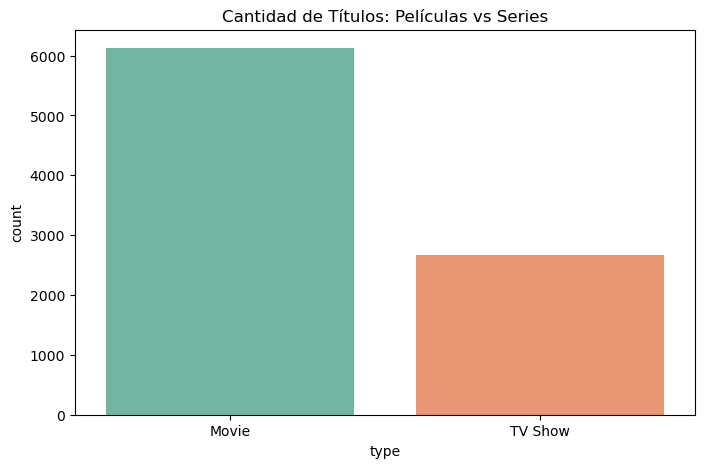

In [ ]:
# 2. Imprimimos los nombres EXACTOS de las columnas para revisarlas
print("Las columnas en tu archivo son:")
print(df.columns.tolist())

# 3. Intentamos hacer el gráfico nuevamente
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Cantidad de Títulos: Películas vs Series')
plt.show()


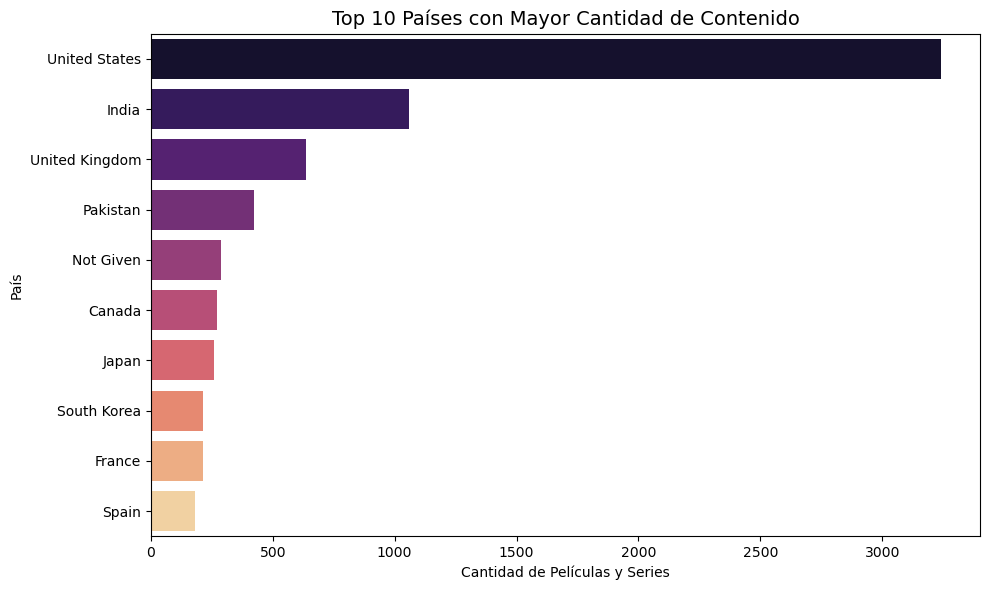

In [ ]:
#Este gráfico cuenta cuántas películas y series 
#tiene cada país y muestra los 10 primeros.

plt.figure(figsize=(10, 6))

# Obtenemos los 10 países más frecuentes contando sus apariciones
top_10_paises = df['country'].value_counts().head(10)

# Al ser nombres largos, una gráfica horizontal (orient='h') se lee mucho mejor
sns.barplot(x=top_10_paises.values, y=top_10_paises.index, palette='magma')

plt.title('Top 10 Países con Mayor Cantidad de Contenido', fontsize=14)
plt.xlabel('Cantidad de Películas y Series')
plt.ylabel('País')
plt.tight_layout()
plt.show()

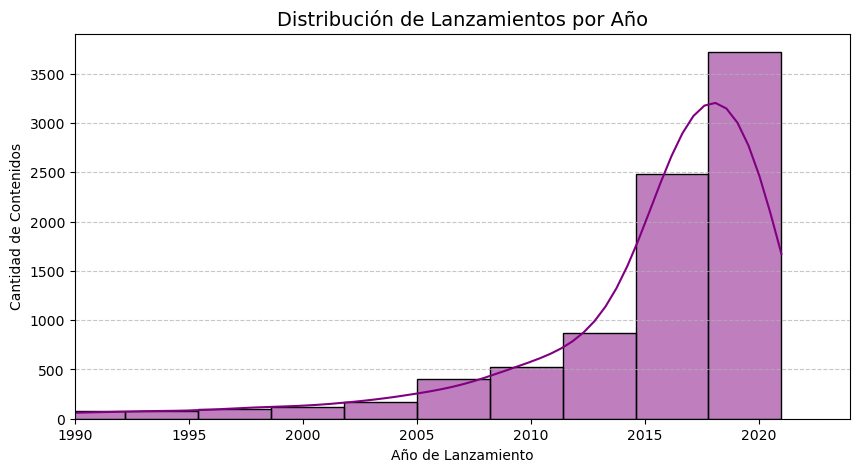

In [ ]:
#¿En qué años se produjeron la mayoría de las
#películas y series que están en la plataforma?
plt.figure(figsize=(10, 5))

# Usamos un histograma acotado desde 1990 para verlo mejor
sns.histplot(data=df, x='release_year', bins=30, kde=True, color='purple')

plt.title('Distribución de Lanzamientos por Año', fontsize=14)
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Cantidad de Contenidos')
plt.xlim(1990, 2024) # Nos enfocamos de 1990 en adelante
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


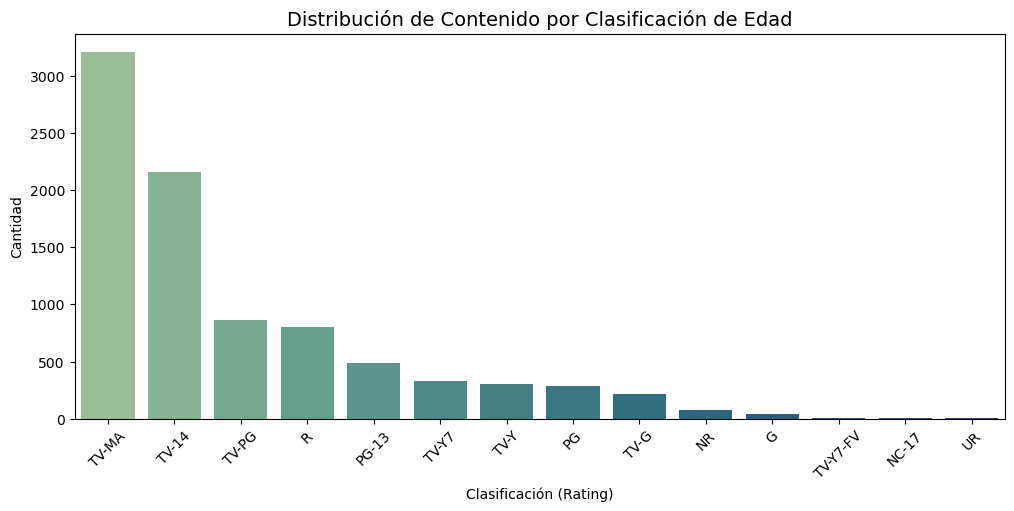

In [ ]:
#Vamos a ver cuáles son las clasificaciones
#(Ratings como TV-MA, PG-13, TV-14, etc.)

plt.figure(figsize=(12, 5))

# El order nos ayudará a organizarlo de mayor a menor número
orden_rating = df['rating'].value_counts().index

sns.countplot(data=df, x='rating', order=orden_rating, palette='crest')

plt.title('Distribución de Contenido por Clasificación de Edad', fontsize=14)
plt.xlabel('Clasificación (Rating)')
plt.ylabel('Cantidad')
plt.xticks(rotation=45) # Giramos un poco los textos para que no se encima
plt.show()


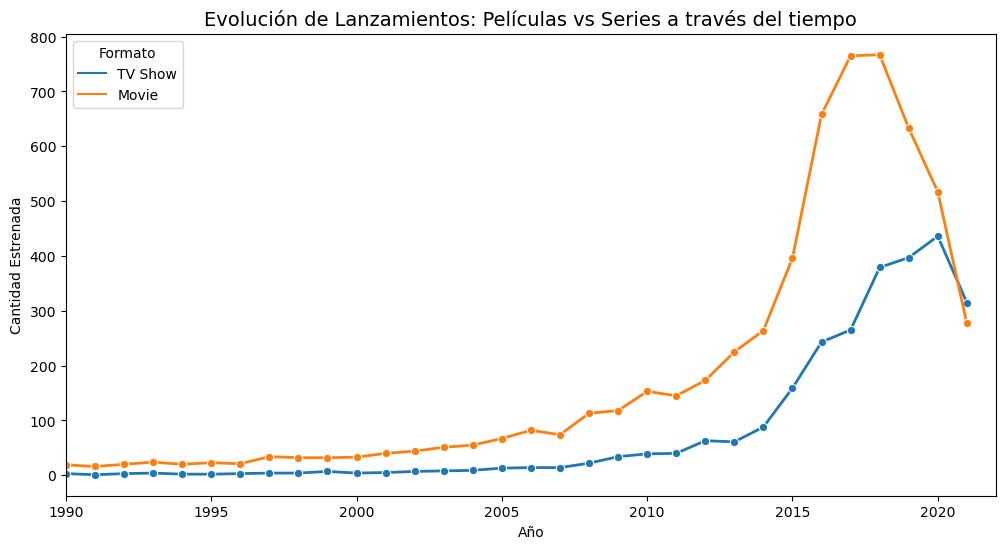

In [ ]:
#Con este gráfico podemos ver si recientemente 
#Netflix ha subido más Series que Películas.
plt.figure(figsize=(12, 6))

# Contamos el número de películas y series por año
tendencia = df.groupby(['release_year', 'type']).size().reset_index(name='count')

sns.lineplot(data=tendencia, x='release_year', y='count', hue='type', marker="o", linewidth=2)

plt.title('Evolución de Lanzamientos: Películas vs Series a través del tiempo', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cantidad Estrenada')
plt.xlim(1990, 2022) # Filtramos para no ver cosas súper antiguas
plt.legend(title='Formato')
plt.show()


In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Carga de datos (Asegúrate de subir el archivo netflix1.csv)
df = pd.read_csv('netflix1.csv', sep=';')

# 2. Preprocesamiento básico
# Convertimos el objetivo 'type' a números: Movie = 0, TV Show = 1
df['type_num'] = df['type'].map({'Movie': 0, 'TV Show': 1})

# 3. Definir variables
X = df[['release_year']] # Característica (Feature)
y = df['type_num']       # Objetivo (Target)

# 4. Crear el modelo usando índice de Gini y una profundidad baja para entenderlo
modelo = DecisionTreeClassifier(criterion='gini', max_depth=2)
modelo.fit(X, y)

# 5. Visualización del Árbol
plt.figure(figsize=(10,6))
plot_tree(modelo, 
          filled=True, 
          feature_names=['Año Lanzamiento'], 
          class_names=['Movie', 'TV Show'])
plt.title("Árbol de Decisión: Clasificación de Contenido")
plt.show()

Error: No connection selected.